# Fine Tune Mixtral-8x-7B using QLoRA
* Notebook by Adam Lang
* Date: 4/9/2025

# What is Mixtral 8x7B?
* Sparse mixture of experts (SMoE) language model from Mistral AI, designed for efficient and powerful language processing.
* This model boasts 46.7 billion parameters, but only uses 13 billion actively during inference, and outperforming Llama-2-70B on most benchmarks.

# Unique Architecture
* What is unique about Mixtral is its unique router network which selects 2 experts to handle the current state during token processing.
  * There are 8 expert models in 1 LLM.
  * At each time step, the router selects 2 experts based on probabilistic decoding.
  * This means that not every token goes to every "expert model"
  * This "distributes the load".
* This allows access to 47B parameters while utilizing only 13B active parameters during inference.
* Mixtral outperforms other language models in various benchmarks, such as mathematics, code generation, and multilingual tasks.

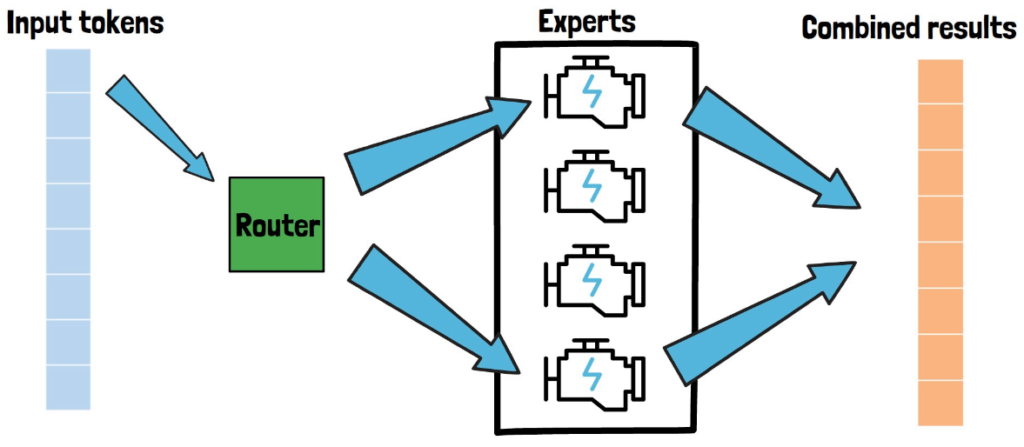



# Benchmarks Performance
* Overall:
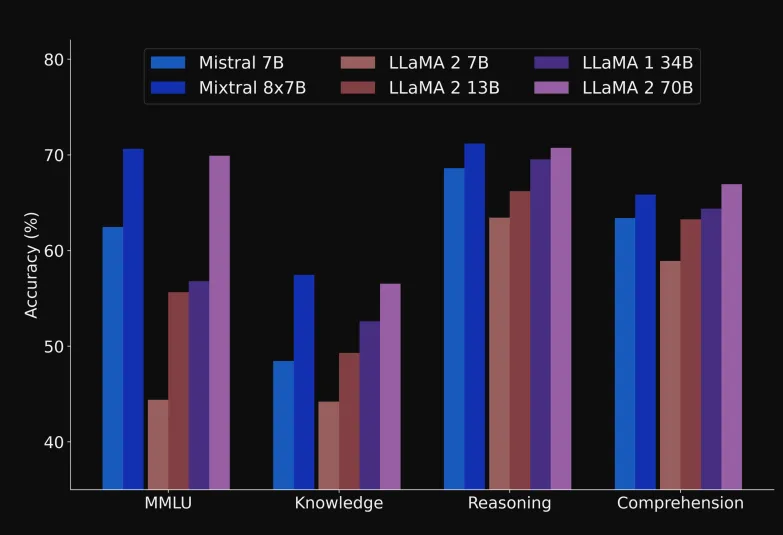


* Mixtral presents less bias than Llama 2 70B as seen here:

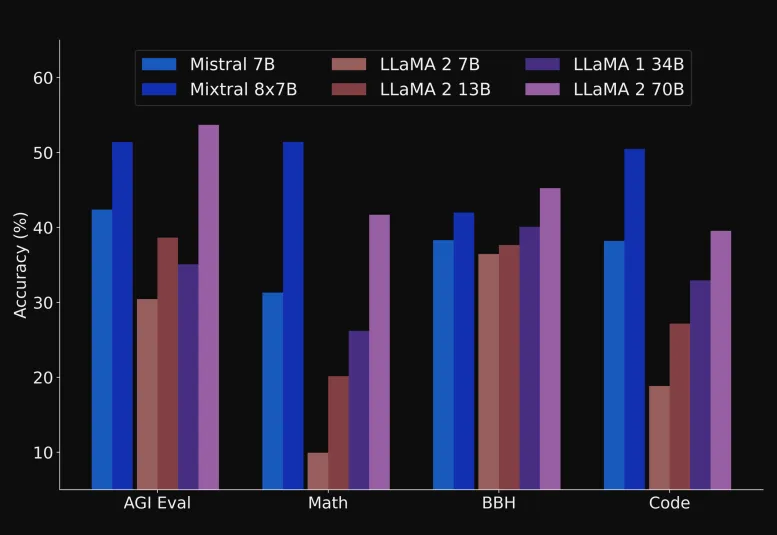


* [Source above](https://thisisrishi.medium.com/introduction-to-mixtral-8x7b-c80dd160b989)

# Mixture of Experts - Why is this a big deal?
1. Pretrained much faster
2. Inference faster (compared to a model with same num of params)
3. HIGH VRAM required....

# Advantages of Mixture of Experts Models
1. Performance Maintenance
    * Mixture of Experts (MoE) models excel in handling diverse and complex data by dynamically assigning specialized experts to different input types.
    * This ensures consistently high performance across various tasks and scenarios.

2. Hallucination Reduction
    * MoE models reduce the occurrence of inaccurate or misleading outputs.
    * By leveraging multiple experts with different specializations, these models produce more nuanced and accurate responses, crucial for applications where precision is key.

3. Adaptability to Diverse Data
    * The strength of MoE models lies in their ability to adapt to various data types.
    * Different experts focus on specific data aspects, allowing the model to handle diverse and unpredictable datasets effectively.

# Disadvantages of Mixture of Experts Models
1. Complexity of model is greater.
2. Overfitting risk is higher.

# Current Rankings of MOE LLMs
* This is the `OPEN-MOE-LLM-LEADERBOARD` on huggingface.
* As of 4/9/2025 the Qwen and Databricks models are ranked higher overall.
* However, on certain benchmarks like the `MMLU` language benchmark this model is still #1.
* Here is the MOE leaderboard: https://huggingface.co/spaces/sparse-generative-ai/open-moe-llm-leaderboard

# QLoRA Fine Tuning Implementation 
* Model: `mistralai/Mixtral-8x7B-v0.1`
* Model Card: https://huggingface.co/mistralai/Mixtral-8x7B-v0.1
* Note: You will need at least 64 GB of VRAM to run this model.



## Install Dependencies

In [ ]:
# %%capture 
# # !pip install flash-attn --no-build-isolation
# #For H100 specifically (which uses CUDA architecture 9.0), you might need to install with specific compilation flags:
# import os
# os.environ['FLASH_ATTENTION_FORCE_BUILD'] = 'TRUE'
# !pip install flash-attn --no-build-isolation

In [ ]:
!pip install flash-attn --no-build-isolation --verbose

In [ ]:
# Install dependencies first
!pip install ninja packaging
!pip install triton==2.0.0

# Set environment variables and reinstall
import os
os.environ['FLASH_ATTENTION_FORCE_BUILD'] = 'TRUE'
!pip uninstall -y flash-attn  # Remove any partial installation
!pip install flash-attn --no-build-isolation --verbose

In [ ]:
!pip install --upgrade pip

In [ ]:
##Verify the installation: After installation, verify that it's correctly installed:
import flash_attn
print(flash_attn.__version__)

In [ ]:
%%capture 
!pip install --upgrade transformers

In [ ]:
%%capture 
!pip install trl==0.12.2

In [ ]:
%%capture  
## upgrade accelerate to use device_map 
!pip install --upgrade accelerate ## this is for compatability with `bitsandbytes` 

In [ ]:
## check accelerate version after upgrade
import accelerate
print(f"Accelerate version: {accelerate.__version__}") 

In [ ]:
%%capture 
!pip install --upgrade bitsandbytes peft datasets

In [ ]:
%%capture 
## upgrade torchvision
!pip install --upgrade torchvision # if you need to upgrade torchvision run this line
!pip install --upgrade torch #upgrade torch version

In [ ]:
# check versions of torch available
import torch
import torchvision 

# print versions
print(f"PyTorch version: {torch.__version__}") 
print(f"Torchvision version: {torchvision.__version__}")

# Check if GPU Available

In [ ]:
# check if GPU is available 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
print(f"Using device: {device}")

# set device for PyTorch operations
if device.type == "cuda":
    torch.cuda.set_device(0) # you can use a different device ID if you have multiple GPUs running

## Hugging Face Notebook Login

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

# Load Dataset
* We will use the `mosaicml/instruct-v3` dataset.
* Model card: https://huggingface.co/datasets/mosaicml/instruct-v3
* Dataset info:
  * Prompt column
  * Response column
  * Source column

In [ ]:
from datasets import load_dataset

## load dataset
instruct_tune_data = load_dataset('mosaicml/instruct-v3')

* Goal is to fine tune a model that generates instructions.
* Thus, we are going to filter the data to ONLY the `dolly_hhrlhf` components.

In [ ]:
## filter dataset
instruct_tune_data = instruct_tune_data.filter(lambda x: x['source'] == 'dolly_hhrlhf')

In [ ]:
## view dataset
instruct_tune_data

# Create Formatted Prompt
* To fine tune the mixtral of experts we need a formatted prompt.
* This is the prompt format we will use where we merge the `prompt` and `response` columns with this template below.
* If you are fine tuning with the INSTRUCT version of the Mixtral model then this is the format you need.
* However using the base model you can use your own format.
```
<s>[INST] Use the provided input to create an instruction that could have been used to generate the response with an LLM.

{input} [/INST]

{response}</s>
```

In [ ]:
## this is how data is currently formatted
instruct_tune_data['train'][0]

Summary
* As we can see above we need to transform this dataset format to align with the model we are using for fine tuning.

In [ ]:
## formatted prompt
def create_prompt(sample):
    """Formatted prompt"""
    bos_token = "<s>"
    original_system_message = "Below is an instruction that describes a task. Write a response that appropriately completes the request."
    system_message = "[INST]Use the provided input to create an instruction that could have ben used to generate the response with an LLM."
    response = sample['prompt'].replace(original_system_message, "").replace("\n\n### Instruction\n", "").replace("\n### Response\n", "").strip()
    input = sample['response']
    eos_token = "</s>"

    full_prompt = ""
    full_prompt += bos_token 
    full_prompt += system_message
    full_prompt += "\n" + input 
    full_prompt += "[INST]"
    full_prompt += response 
    full_prompt += response
    full_prompt += eos_token

    return full_prompt

In [ ]:
## example using the function above
create_prompt(instruct_tune_data['train'][0])

# Load Base Model from Hugging Face
* We load model and quantize it into `4_bit` quantization using `BitsAndBytes`.
* We will use `bfloat16` as the dtype.
* The model being used is the instruct-fine-tuned model instead of the base model.
* If you are going to fine-tune the base model you need A LOT MORE DATA!

In [ ]:
## base model ckpt (NOT INSTRUCT version)
model_id = "mistralai/Mixtral-8x7B-v0.1"

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

In [ ]:
# Setup quantization config
nf4_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
) 

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=nf4_config,
    use_cache=False,
    attn_implementation="flash_attention_2", ## GPU needs to be enable to handle flash attn
    )

Note about code below
* We want to pad the end of sequence tokens.
* This is so that if we have max sequences of lets say "200" and we have a sequence of 150, we pad the space.

In [ ]:
## load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)
## set pad tokens
tokenizer.pad_token = tokenizer.eos_token ## end of seq token
tokenizer.padding_side = "right"

# Testing the Base Model WITHOUT Fine Tuning
* First lets see what the "raw" output of the base model is without fine tuning just to have as a baseline.

In [ ]:
## setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

In [ ]:
## function to generate raw response
def gen_response(prompt, model): 
    """
    Function to generate raw outputs from base model without fine tuning.
    """
    ## tokenize input
    encoded_input = tokenizer(prompt, return_tensors="pt", add_special_tokens=True)
    ## encode input & send to device
    model_inputs = encoded_input.to(device)

    ## get ids
    generated_ids = model.generate(**model_inputs,
                                  max_new_tokens=512,
                                  do_sample=True,
                                  pad_token_id=tokenizer.eos_token_id)

    ## decode llm outputs
    decoded_output = tokenizer.batch_decode(generated_ids)

    return decoded_output[0].replace(prompt, "")

In [ ]:
## test_prompt
prompt = """<s>[INST]Use the provided input to create an instruction that could have ben used to generate the response with an LLM.
There are more than 12,000 species of grass. The most common is Kentucky Bluegrass, because it grows quickly, easily, and is soft to the touch. 
Rygrass is shiny and bright green colored. Fescues are dark green and shiny. Bermuda grass is harder but can grow in drier soil.[\INST]
"""

In [ ]:
## run test_prompt 
gen_response(prompt, model)

Summary/Observation
* We can see the output is very raw and "all over the place".
* We will have to see what happens when we fine tune the model.

# Tokenization Analysis
* It is very important to always look at the tokens that your model is going to generate on your input data before you fine-tune a model regardless of whether the model is an encoder, decoder or encoder-decoder.
* It is important to "become one with the data" to better understand the tokens for things such as:

1. Cost (if using a paid API LLM)
2. Token usage & Caching prompts
3. Scalability
4. Sequence generation -- if the inputs are larger than the context window of the model that is a big problem and the model fine-tuned will not perform any better than it did as a base model.
5. Compute Memory

* Another concern is that this Mixtral model "out of the box" supports token lengths of up to 32,000. If your data is much shorter in length per sequence than the results will be suboptimal and you should adapt the token generation to the shorter sequences.

In [ ]:
## tokenize prompts
def tokenize_prompts(prompt):
    return tokenizer(create_prompt(prompt))

## apply function to train and val data
tokenized_train_dataset = instruct_tune_data['train'].map(tokenize_prompts)
tokenized_val_dataset = instruct_tune_data['test'].map(tokenize_prompts)

In [ ]:
%%capture
!pip install matplotlib

In [ ]:
## plot tokens
import matplotlib.pyplot as plt
%matplotlib inline 

## function to plot
def plot_token_len(tokenized_train_dataset, tokenized_val_dataset):
    """
    Function to plot tokenized data.
    """
    lengths = [len(x['input_ids']) for x in tokenized_train_dataset]
    lengths += [len(x['input_ids']) for x in tokenized_val_dataset]
    print(len(lengths))

    ## plot histogram
    plt.figure(figsize=(12,8))
    plt.hist(lengths, bins=40, alpha=0.7, color='green')
    plt.xlabel('Length of input_ids')
    plt.ylabel('Frequency')
    plt.title('Distribution of Sequence Lengths of input_ids to LLM')
    plt.xlim([0, 1500])
    plt.show();

## plot tokens
plot_token_len(tokenized_train_dataset, tokenized_val_dataset)

In [ ]:
## function to make boxplot
def boxplot_token_len(tokenized_train_dataset, tokenized_val_dataset):
    """
    Function to plot tokenized data.
    """
    lengths = [len(x['input_ids']) for x in tokenized_train_dataset]
    lengths += [len(x['input_ids']) for x in tokenized_val_dataset]
    print(len(lengths))

    ## plot histogram
    plt.figure(figsize=(12,8))
    plt.boxplot(lengths)
    plt.xlabel('Length of input_ids')
    plt.ylabel('Frequency')
    plt.title('Distribution of Sequence Lengths of input_ids to LLM')
    #plt.xlim([0, 1500])
    plt.show();

## plot tokens
boxplot_token_len(tokenized_train_dataset, tokenized_val_dataset)

Summary
* We can see most of the sequences are less than 2000 tokens in length.
* This is a good reason to finetune the model since the max sequence length is currently 32k.

In [ ]:
## let view the model architecture
print(model)

Summary
* The linear layers are the ones above that we are going to be fine tuning with LoRA:
```
(block_sparse_moe): MixtralSparseMoeBlock(
          (gate): Linear4bit(in_features=4096, out_features=8, bias=False)
          (experts): ModuleList(
            (0-7): 8 x MixtralBlockSparseTop2MLP(
              (w1): Linear4bit(in_features=4096, out_features=14336, bias=False)
              (w2): Linear4bit(in_features=14336, out_features=4096, bias=False)
              (w3): Linear4bit(in_features=4096, out_features=14336, bias=False)
              (act_fn): SiLU()
```

# Training Setup with peft
* We will use the peft library from hugging face to fine tune the model.

* As a reminder, these are the parameters we are concerned with:
```
LoraConfig:
r: rank, LoRA attention dimension. 8 is ideal.
lora_alpha: parameter for LoRA scaling.
lora_dropout: dropout probability for LoRA layers. Regularization. Can help reduce overfitting.
bias: bias type for LoRA. Can be ‘none’, ‘all’ or ‘lora_only’.
target_modules: names of the modules to which the adapter should apply. You can find the module names by simply printing the model. For example, [“q_proj”, “k_proj”, “v_proj”, “o_proj”, ”gate_proj”, “up_proj”]
```

In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

## setup peft config
peft_config = LoraConfig(
    lora_alpha=16,
    lora_dropout=0.1,
    r=64,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj","down_proj","lm_head"],
    task_type="CAUSAL_LM", ## text-generation
)
        

### Prepare model to be trained in 4bit quantization
* To prepare model for QLoRA training, we use the `prepare_model_for_kbit_training()` function.
* This function initializes the model for QLoRA by setting up the necessary configurations.



In [ ]:
## apply lora adapters to model
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, peft_config)

### Get trainable parameters
* We should always see howmany parameters are trainable.

In [ ]:
## trainable param function
def print_trainable_params(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_params = 0
    for _, param in model.named_parameters():
        all_params += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} | all params: {all_params} | trainable%: {100 * trainable_params / all_params}"
    )

In [ ]:
## get the trainable params
print_trainable_params(model)

Summary
* Aha! We can see that only about 0.24% of the models parameters are trainable.

In [ ]:
## lets view the model again after attaching the lora adapters
print(model)

# Hyper-parameters for Training Model
* The parameters here will depend upon the duration we want to train the model for.
* The most imporant ones are:
  1. `num_train_epochs/max_steps`
     * This is how many iterations over the data we want.
     * KEY HERE IS DO NOT START WITH TOO MANY OR THE MODEL WILL BE OVERFIT!!
  2. `learning_rate`
     * Controls speed of convergence.

In [ ]:
## if you are using more than 1 GPU than use data parallelization across GPUs
if torch.cuda.device_count() > 1: 
    print(torch.cuda.device_count())
    model.is_parallelizable = True 
    model.model_parallel = True

## Training Arguments for Fine Tuning

In [ ]:
from transformers import TrainingArguments

## setup args
args = TrainingArguments(
    output_dir = "Mixtral_fine_tune",
    # num_train_epochs=5,
    max_steps=250, # comment this out if you want to train in epochs instead
    per_device_train_batch_size=32,
    warmup_steps=1,
    logging_steps=10,
    save_strategy="epoch",
    #evaluation_strategy="epoch", ## uncomment this if you are training in epochs instead
    eval_strategy="steps",
    eval_steps=10, # comment this out if you want to eval at every epoch
    learning_rate=2.5e-5,
    bf16=True,
    # lr_scheduler_type='constant',
)

In [ ]:
## trainer setup
from trl import SFTTrainer

## set max seq len
max_seq_length = 1024

## trainer
trainer = SFTTrainer(
    model=model,
    peft_config=peft_config,
    max_seq_length=max_seq_length,
    tokenizer=tokenizer,
    packing=True,
    formatting_func=create_prompt, # this applies create_prompt func mapping to all train and test data
    args=args,
    train_dataset=instruct_tune_data['train'],
    eval_dataset=instruct_tune_data['test'],
)

# Save Model and Push to Hub

In [1]:
#!pip install huggingface-hub -qU

In [2]:
# trainer.push_to_hub("<your repo name>/mixtral-base-instruct-generation-fine-tune")

# Test Fine-Tuned Model

In [ ]:
## use same function above
## function to generate raw response
def gen_response(prompt, model): 
    """
    Function to generate raw outputs from base model without fine tuning.
    """
    ## tokenize input
    encoded_input = tokenizer(prompt, return_tensors="pt", add_special_tokens=True)
    ## encode input & send to device
    model_inputs = encoded_input.to(device)

    ## get ids
    generated_ids = model.generate(**model_inputs,
                                  max_new_tokens=150, # change tokens to 150 from 512
                                  do_sample=True,
                                  pad_token_id=tokenizer.eos_token_id)

    ## decode llm outputs
    decoded_output = tokenizer.batch_decode(generated_ids)

    return decoded_output[0].replace(prompt, "")

In [ ]:
## test_prompt
prompt = """<s>[INST]Use the provided input to create an instruction that could have ben used to generate the response with an LLM.
There are more than 12,000 species of grass. The most common is Kentucky Bluegrass, because it grows quickly, easily, and is soft to the touch. 
Rygrass is shiny and bright green colored. Fescues are dark green and shiny. Bermuda grass is harder but can grow in drier soil.[\INST]
"""